# GrC Image Matting on MIAS - Layers 2–5, Evaluation and Ablation

Runs the remaining four layers end to end, evaluates every alpha map against the circular ground truth, and runs the four-arm ablation.

Writes to Drive: `svm_layer4.joblib`, `svm_scaler.joblib`, `alpha_maps_full.npz`, `evaluation_per_*.csv`, `ablation_table.csv`, `final_results.json`, `results_summary.txt`.

## Setup and state recovery

Everything Notebooks 1 and 2 produced is reloaded from Drive here, and the recovery cell asserts that the
restored state is complete and that the train/test sets are still disjoint before
any computation starts.

In [ ]:
# Imports
!pip install -q opencv-python scikit-learn scipy tqdm joblib

import os
import json
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from scipy import ndimage
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import spsolve
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import joblib

warnings.filterwarnings('ignore')
print("Imports OK.")

Imports OK.


In [ ]:
# Mount Drive and load config
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT   = "/content/drive/MyDrive/mias_grc_project_v2"
CONFIG_PATH  = os.path.join(DRIVE_ROOT, "config.json")

DEFAULTS = {
    "SEED": 42,
    "TARGET_CLASSES": ["CIRC", "SPIC", "MISC", "NORM"],
    "MASS_CLASSES": ["CIRC", "SPIC", "MISC"],
    "LAMBDA_VAL": 5.0,
    "PATCH_SIZES": [3, 5, 7],
    "PATCH_SINGLE": 5,
    "HISTOGRAM_WINDOW": 7,
    "HISTOGRAM_STRIDE": 1,
    "SVM_C_VALUES": [0.1, 1, 10],
    "SVM_GAMMA_VALUES": ["scale", "auto"],
    "HYBRID_GAMMA": 0.9,
    "MAX_NODES": 2500,
    "LAMBDA_PROPAGATION": 100.0,
    "ALPHA_THRESHOLD": 0.5,
    "HD95_PERCENTILE": 95,
}

if os.path.exists(CONFIG_PATH):
    CONFIG = json.load(open(CONFIG_PATH))
    print("Loaded config.json from Drive.")
else:
    CONFIG = dict(DEFAULTS)
    CONFIG["DRIVE_ROOT"] = DRIVE_ROOT
    print("config.json not found. Using built-in defaults and writing the file.")

DIR_MAP = {
    "OUTPUTS_DIR"     : "outputs",
    "PREPROCESSED_DIR": "preprocessed",
    "TRIMAPS_DIR"     : "trimaps",
    "ALPHAS_DIR"      : "alpha_maps",
    "MODELS_DIR"      : "models",
    "RESULTS_DIR"     : "results",
    "LOGS_DIR"        : "logs",
    "FIGURES_DIR"     : "figures",
}
for var, folder in DIR_MAP.items():
    p = os.path.join(DRIVE_ROOT, folder)
    os.makedirs(p, exist_ok=True)
    CONFIG[var] = p
CONFIG["ALPHA_MAPS_DIR"] = CONFIG["ALPHAS_DIR"]   # alias, harmless

for k, v in DEFAULTS.items():
    CONFIG.setdefault(k, v)

with open(CONFIG_PATH, 'w') as f:
    json.dump(CONFIG, f, indent=2)

globals().update(CONFIG)
SEED = CONFIG["SEED"]
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

MAX_TRAIN_PATCHES_PER_IMG = 300
LAP_WINDOW  = 3
LAP_EPSILON = 1e-7
MAX_GRID    = 8000
MAX_FIT     = 20000
ABLATION_N_PER_CLASS = 8
ABLATION_KEYS = ["baseline_3x3_manual", "mod2_5x5_single_scale",
                 "mod1234_no_hybrid", "full_method"]

print(f"  Seed          : {SEED}")
print(f"  Patch sizes   : {PATCH_SIZES}")
print(f"  Hybrid gamma  : {HYBRID_GAMMA}")
print(f"  Max nodes     : {MAX_NODES}")

Mounted at /content/drive
Loaded config.json from Drive.
  Seed          : 42
  Patch sizes   : [3, 5, 7]
  Hybrid gamma  : 0.9
  Max nodes     : 2500


In [ ]:
# Restore dataframe, ROIs, trimaps
final_df_loaded = pd.read_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"))
metadata_df     = pd.read_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"))

roi_archive    = np.load(os.path.join(PREPROCESSED_DIR, "rois.npz"))
trimap_archive = np.load(os.path.join(TRIMAPS_DIR, "trimaps.npz"))

preprocessed_results = {}
for image_id in roi_archive.files:
    preprocessed_results[image_id] = {
        'image_id': image_id,
        'roi'     : roi_archive[image_id],
        'trimap'  : trimap_archive[image_id] if image_id in trimap_archive.files else None,
    }

for _, row in metadata_df.iterrows():
    iid = row['image_id']
    if iid in preprocessed_results:
        preprocessed_results[iid]['total_r']  = row['total_r']
        preprocessed_results[iid]['roi_size'] = row['roi_size']

n_trimap = sum(1 for r in preprocessed_results.values() if r['trimap'] is not None)
print(f"final_df_loaded      : {len(final_df_loaded)} rows")
print(f"preprocessed_results : {len(preprocessed_results)} cases ({n_trimap} with trimap)")

final_df_loaded      : 105 rows
preprocessed_results : 105 cases (55 with trimap)


In [ ]:
# Restore templates, split, Layer 1 maps
tpath = os.path.join(MODELS_DIR, "kmeans_templates.npy")
if not os.path.exists(tpath):
    tpath = os.path.join(MODELS_DIR, "kmeans_templates_K16.npy")
    print("Note: using the legacy filename kmeans_templates_K16.npy.")
    print("      Despite the name it holds K=8. K is read from the array shape.")

templates   = np.load(tpath)
K_TEMPLATES = templates.shape[0]

meta_path = os.path.join(MODELS_DIR, "template_meta.json")
if os.path.exists(meta_path):
    tmeta = json.load(open(meta_path))
    assert tmeta['K'] == K_TEMPLATES, "template_meta.json disagrees with the array"
    print(f"template_meta.json confirms K = {tmeta['K']}")

with open(os.path.join(RESULTS_DIR, "train_test_split.json")) as f:
    split_data = json.load(f)
train_ids = set(split_data['train_ids'])
test_ids  = set(split_data['test_ids'])

layer1_ms_maps = {}
for ps in PATCH_SIZES:
    arch = np.load(os.path.join(OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz"))
    for img_id in arch.files:
        if img_id not in layer1_ms_maps:
            row = final_df_loaded[final_df_loaded['image_id'] == img_id]
            layer1_ms_maps[img_id] = {
                'lipw_stack': np.zeros((*arch[img_id].shape, len(PATCH_SIZES)), np.float32),
                'cls': row['class'].values[0] if len(row) else 'UNKNOWN',
            }
        layer1_ms_maps[img_id]['lipw_stack'][:, :, PATCH_SIZES.index(ps)] = arch[img_id]

print(f"Templates : {templates.shape}  ->  K_TEMPLATES = {K_TEMPLATES}")
print(f"Train ids : {len(train_ids)}")
print(f"Test ids  : {len(test_ids)}")
print(f"Layer 1   : {len(layer1_ms_maps)} multi-scale stacks")

template_meta.json confirms K = 10
Templates : (10, 5, 5)  ->  K_TEMPLATES = 10
Train ids : 38
Test ids  : 67
Layer 1   : 105 multi-scale stacks


In [ ]:
# Recovery verification
def verify_recovery():
    checks = {
        "final_df_loaded rows"   : len(final_df_loaded) > 0,
        "preprocessed_results"   : len(preprocessed_results) == len(final_df_loaded),
        "templates 3D array"     : templates.ndim == 3,
        "K from array shape"     : K_TEMPLATES == templates.shape[0],
        "train/test split loaded": len(train_ids) > 0 and len(test_ids) > 0,
        "no train/test leakage"  : len(train_ids & test_ids) == 0,
        "layer1 maps complete"   : len(layer1_ms_maps) == len(final_df_loaded),
    }
    print("=" * 52)
    print("RECOVERY CHECK")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    return ok

recovery_ok = verify_recovery()
assert recovery_ok, "Recovery failed. Run notebooks 1 and 2 before this one."
print("State restored. Ready for Section 9.")

RECOVERY CHECK
  OK   final_df_loaded rows
  OK   preprocessed_results
  OK   templates 3D array
  OK   K from array shape
  OK   train/test split loaded
  OK   no train/test leakage
  OK   layer1 maps complete
State restored. Ready for Section 9.


## Section 9 - Layer 2: signed template matching

Each Layer 1 texture map is matched against the K learned templates, producing a
K-channel score map.

In [ ]:
def match_templates_signed(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps).astype(np.float32)

    T  = templates.reshape(K, ps * ps).astype(np.float32)
    Tc = T - T.mean(axis=1, keepdims=True)
    W  = np.sign(Tc)
    W[W == 0] = 1.0

    Pc = pf - pf.mean(axis=1, keepdims=True)

    num   = Pc @ W.T
    denom = (np.linalg.norm(Pc, axis=1, keepdims=True) *
             np.linalg.norm(W, axis=1)[None, :] + 1e-8)
    corr  = num / denom
    score = (corr + 1.0) * 0.5
    return score.reshape(h, w, K).astype(np.float32)


def match_templates_old(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps)
    tf      = templates.reshape(K, ps * ps)
    out     = np.zeros((h * w, K), dtype=np.float32)

    for k in range(K):
        t = tf[k]
        high = (t >= 0.7)
        low  = (t <= 0.3)
        med  = ~high & ~low
        sat  = np.zeros((h * w, ps * ps), dtype=np.float32)
        if high.any():
            sat[:, high] = pf[:, high]
        if low.any():
            sat[:, low] = 1.0 - pf[:, low]
        if med.any():
            sat[:, med] = 1.0 - np.abs(pf[:, med] - 0.5) * 2.0
        b = np.maximum(0, sat[:, :-1] + sat[:, 1:] - 1)
        out[:, k] = b.mean(axis=1)

    return out.reshape(h, w, K)

print("Both matchers defined (old is diagnostic only).")

Both matchers defined (old is diagnostic only).


In [ ]:
# Layer 3 histogram function
def compute_histogram_map_fast(score_map, window_size=7, stride=1):
    h, w, k = score_map.shape
    half    = window_size // 2

    padded = np.pad(score_map, ((half, half), (half, half), (0, 0)),
                    mode='reflect').astype(np.float32)
    cs       = padded.cumsum(axis=0).cumsum(axis=1)
    integral = np.pad(cs, ((1, 0), (1, 0), (0, 0)), mode='constant')

    rows = list(range(0, h, stride))
    cols = list(range(0, w, stride))
    out  = np.zeros((len(rows), len(cols), k), dtype=np.float32)

    for oi, i in enumerate(rows):
        for oj, j in enumerate(cols):
            r1, c1 = i, j
            r2, c2 = i + window_size, j + window_size
            hist = (integral[r2, c2] - integral[r1, c2]
                    - integral[r2, c1] + integral[r1, c1])
            s = hist.sum()
            out[oi, oj] = hist / s if s > 1e-8 else np.ones(k, dtype=np.float32) / k

    return out

print("Layer 3 histogram function defined.")

Layer 3 histogram function defined.


In [ ]:
# Helper to pick one sample per class
def sample_per_class(df, pool):
    out = {}
    for cls in TARGET_CLASSES:
        for _, r in df[df['class'] == cls].iterrows():
            if r['image_id'] in pool:
                out[cls] = r
                break
    return out

print("Sample helper defined.")

Sample helper defined.


In [ ]:
# DRIVER - batch Layer 2 with the corrected matcher
print("Building Layer 2 score maps (signed matching)...\n")
layer2_maps = {}
t0 = time.time()
scale_idx = PATCH_SIZES.index(PATCH_SINGLE)

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="Layer 2"):
    iid = row['image_id']
    if iid not in layer1_ms_maps:
        continue
    lipw = layer1_ms_maps[iid]['lipw_stack'][:, :, scale_idx]
    layer2_maps[iid] = {
        'score_map': match_templates_signed(lipw, templates),
        'cls'      : row['class'],
    }

print(f"\nDone: {len(layer2_maps)} score maps in {(time.time()-t0)/60:.1f} min")

np.savez_compressed(
    os.path.join(OUTPUTS_DIR, "layer2_score_maps_signed.npz"),
    **{k: v['score_map'] for k, v in layer2_maps.items()}
)
mb = os.path.getsize(os.path.join(OUTPUTS_DIR, "layer2_score_maps_signed.npz")) / 1e6
print(f"Saved layer2_score_maps_signed.npz ({mb:.1f} MB)")

Building Layer 2 score maps (signed matching)...



Layer 2: 100%|██████████| 105/105 [00:01<00:00, 74.58it/s]



Done: 105 score maps in 0.0 min
Saved layer2_score_maps_signed.npz (117.5 MB)


In [ ]:
# Verification
def verify_section9():
    checks = {
        "layer2_maps populated"  : len(layer2_maps) == len(final_df_loaded),
        "All have score_map"     : all('score_map' in d for d in layer2_maps.values()),
        "Score map shape (H,W,K)": all(d['score_map'].ndim == 3 and
                                       d['score_map'].shape[2] == K_TEMPLATES
                                       for d in layer2_maps.values()),
        "Scores in [0,1]"        : all(d['score_map'].min() >= 0 and d['score_map'].max() <= 1
                                       for d in layer2_maps.values()),
        "No NaN"                 : all(not np.isnan(d['score_map']).any()
                                       for d in layer2_maps.values()),
        "Saved to Drive"         : os.path.exists(os.path.join(
                                       OUTPUTS_DIR, "layer2_score_maps_signed.npz")),
    }
    print("=" * 52)
    print("SECTION 9 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Ready for Section 10." if ok else "Review failures.")
    return ok

section9_ok = verify_section9()

SECTION 9 VERIFICATION
  OK   layer2_maps populated
  OK   All have score_map
  OK   Score map shape (H,W,K)
  OK   Scores in [0,1]
  OK   No NaN
  OK   Saved to Drive
Ready for Section 10.


## Section 10 - Layer 3: sliding-window histograms

Pools the Layer 2 score map into a per-pixel histogram over the K templates, using
an integral-image formulation so the window sum is O(1) per position.

In [ ]:
# DRIVER - batch Layer 3
print("Building Layer 3 histogram maps...\n")
layer3_maps = {}
t0 = time.time()

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="Layer 3"):
    iid = row['image_id']
    if iid not in layer2_maps:
        continue
    layer3_maps[iid] = {
        'hist_map': compute_histogram_map_fast(layer2_maps[iid]['score_map'],
                                               HISTOGRAM_WINDOW, HISTOGRAM_STRIDE),
        'cls'     : row['class'],
    }

print(f"\nDone: {len(layer3_maps)} histogram maps in {(time.time()-t0)/60:.1f} min")

np.savez_compressed(
    os.path.join(OUTPUTS_DIR, "layer3_histogram_maps_signed.npz"),
    **{k: v['hist_map'] for k, v in layer3_maps.items()}
)
mb = os.path.getsize(os.path.join(OUTPUTS_DIR, "layer3_histogram_maps_signed.npz")) / 1e6
print(f"Saved layer3_histogram_maps_signed.npz ({mb:.1f} MB)")

Building Layer 3 histogram maps...



Layer 3: 100%|██████████| 105/105 [00:31<00:00,  3.29it/s]



Done: 105 histogram maps in 0.5 min
Saved layer3_histogram_maps_signed.npz (119.0 MB)


In [ ]:
# Template utilisation
usage = np.zeros(K_TEMPLATES)
for d in layer3_maps.values():
    dom = np.argmax(d['hist_map'], axis=2)
    usage += np.bincount(dom.ravel(), minlength=K_TEMPLATES)
usage_new = 100 * usage / usage.sum()

print("Template utilisation AFTER the fix:")
print("-" * 46)
for t in range(K_TEMPLATES):
    print(f"  T{t:2d}: {usage_new[t]:5.2f}%  " + "#" * int(usage_new[t] / 2))
unused_new = int((usage_new < 0.1).sum())
print(f"\nTemplates with <0.1% usage: {unused_new} / {K_TEMPLATES}")
print("Section 10 with the old matcher reported 6 / 8 unused.")

with open(os.path.join(RESULTS_DIR, "template_utilisation.json"), 'w') as f:
    json.dump({
        'before': {'unused': 6, 'usage_pct': [31.56, 68.44, 0, 0, 0, 0, 0, 0]},
        'after' : {'unused': unused_new, 'usage_pct': [float(x) for x in usage_new]},
    }, f, indent=2)
print("Saved template_utilisation.json")

if unused_new > K_TEMPLATES // 2:
    print()
    print("WARNING: more than half the templates are still unused.")
    print("Do not train the SVM on this feature. Investigate first.")

Template utilisation AFTER the fix:
----------------------------------------------
  T 0: 12.58%  ######
  T 1:  0.48%  
  T 2:  0.87%  
  T 3:  7.05%  ###
  T 4:  3.10%  #
  T 5: 19.41%  #########
  T 6: 17.83%  ########
  T 7:  5.16%  ##
  T 8: 15.05%  #######
  T 9: 18.48%  #########

Templates with <0.1% usage: 0 / 10
Section 10 with the old matcher reported 6 / 8 unused.
Saved template_utilisation.json


In [ ]:
# Per-dimension discriminative check
def dimension_check(layer3_maps, preprocessed_results):
    mass_vals = [[] for _ in range(K_TEMPLATES)]
    bg_vals   = [[] for _ in range(K_TEMPLATES)]

    for iid, d in layer3_maps.items():
        tm = preprocessed_results[iid]['trimap']
        if tm is None:
            continue
        hm = d['hist_map']
        hh, ww = hm.shape[:2]
        if tm.shape != (hh, ww):
            tm = cv2.resize(tm, (ww, hh), interpolation=cv2.INTER_NEAREST)
        wm, bm = (tm == 255), (tm == 0)
        if wm.sum() == 0 or bm.sum() == 0:
            continue
        for k in range(K_TEMPLATES):
            mass_vals[k].extend(hm[:, :, k][wm].tolist())
            bg_vals[k].extend(hm[:, :, k][bm].tolist())

    print(f"{'Dim':<6}{'Mass mean':>12}{'BG mean':>12}{'Diff':>10}")
    print("-" * 42)
    means = []
    for k in range(K_TEMPLATES):
        if not mass_vals[k] or not bg_vals[k]:
            continue
        mm, bb = float(np.mean(mass_vals[k])), float(np.mean(bg_vals[k]))
        means.append(round(mm, 4))
        print(f"T{k:<5}{mm:>12.4f}{bb:>12.4f}{mm-bb:>+10.4f}")
    print("-" * 42)
    print(f"Distinct mass means: {len(set(means))} / {K_TEMPLATES}")
    print("With the old matcher this was 2 distinct values across 8 dimensions.")
    return means

dim_means = dimension_check(layer3_maps, preprocessed_results)

Dim      Mass mean     BG mean      Diff
------------------------------------------
T0          0.1023      0.1000   +0.0023
T1          0.0970      0.0995   -0.0024
T2          0.1029      0.1005   +0.0024
T3          0.1000      0.1011   -0.0011
T4          0.0980      0.1003   -0.0023
T5          0.1032      0.1015   +0.0016
T6          0.1022      0.1005   +0.0017
T7          0.0967      0.0990   -0.0023
T8          0.0996      0.0994   +0.0003
T9          0.0981      0.0982   -0.0002
------------------------------------------
Distinct mass means: 10 / 10
With the old matcher this was 2 distinct values across 8 dimensions.


In [ ]:
# Verification
def verify_section10():
    checks = {
        "layer3_maps populated"   : len(layer3_maps) == len(final_df_loaded),
        "All have hist_map"       : all('hist_map' in d for d in layer3_maps.values()),
        "K channels correct"      : all(d['hist_map'].shape[2] == K_TEMPLATES
                                        for d in layer3_maps.values()),
        "Histograms sum to ~1"    : all(abs(d['hist_map'].sum(axis=2).mean() - 1.0) < 0.01
                                        for d in layer3_maps.values()),
        "No NaN"                  : all(not np.isnan(d['hist_map']).any()
                                        for d in layer3_maps.values()),
        "More than 2 templates"   : int((usage_new >= 0.1).sum()) > 2,
        "Saved to Drive"          : os.path.exists(os.path.join(
                                        OUTPUTS_DIR, "layer3_histogram_maps_signed.npz")),
    }
    print("=" * 52)
    print("SECTION 10 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Ready for Section 11." if ok else "Review failures.")
    return ok

section10_ok = verify_section10()

SECTION 10 VERIFICATION
  OK   layer3_maps populated
  OK   All have hist_map
  OK   K channels correct
  OK   Histograms sum to ~1
  OK   No NaN
  OK   More than 2 templates
  OK   Saved to Drive
Ready for Section 11.


## Section 11 - Layer 4: RBF-SVM pixel classification

Trains the pixel classifier on trimap-labelled positions, with NORM cases excluded since they contain no mass to label.

The base paper specifies a PSVM; this uses
scikit-learn's RBF-SVM instead, which applies to both dataset phases. 

In [ ]:
# Feature table builder function
def build_feature_table(layer3_maps, preprocessed_results, df,
                        id_filter, max_per_img=MAX_TRAIN_PATCHES_PER_IMG):
    """Collects trimap-labelled pixels into (X, y, groups).
    label 1 = mass (trimap 255), label 0 = background (trimap 0)"""
    X, y, groups = [], [], []
    rng = np.random.default_rng(SEED)

    for _, row in df.iterrows():
        iid, cls = row['image_id'], row['class']
        if cls == 'NORM':
            continue
        if iid not in id_filter or iid not in layer3_maps:
            continue

        tm = preprocessed_results[iid]['trimap']
        if tm is None:
            continue

        hm = layer3_maps[iid]['hist_map']
        hh, ww = hm.shape[:2]
        if tm.shape != (hh, ww):
            tm = cv2.resize(tm, (ww, hh), interpolation=cv2.INTER_NEAREST)

        for val, label in [(255, 1), (0, 0)]:
            pos = np.argwhere(tm == val)
            if len(pos) == 0:
                continue
            if len(pos) > max_per_img:
                pos = pos[rng.choice(len(pos), max_per_img, replace=False)]
            for (i, j) in pos:
                X.append(hm[i, j, :])
                y.append(label)
                groups.append(iid)

    return np.array(X, dtype=np.float32), np.array(y), np.array(groups)

print("Feature table builder defined.")

Feature table builder defined.


In [ ]:
# DRIVER - build train and test tables
X_train, y_train, g_train = build_feature_table(
    layer3_maps, preprocessed_results, final_df_loaded, train_ids)
X_test, y_test, g_test = build_feature_table(
    layer3_maps, preprocessed_results, final_df_loaded, test_ids)

print(f"Train: X={X_train.shape}  mass={int(y_train.sum())}  bg={int((y_train==0).sum())}")
print(f"Test : X={X_test.shape}   mass={int(y_test.sum())}  bg={int((y_test==0).sum())}")
print(f"Train images: {len(set(g_train))}   Test images: {len(set(g_test))}")

assert len(set(g_train) & set(g_test)) == 0, "Train/test image leakage."
assert X_train.shape[1] == K_TEMPLATES, "Feature width does not match K."
print("No image-level leakage. Feature width matches K.")

Train: X=(22800, 10)  mass=11400  bg=11400
Test : X=(10200, 10)   mass=5100  bg=5100
Train images: 38   Test images: 17
No image-level leakage. Feature width matches K.


In [ ]:
# DRIVER - scale features and grid search
scaler    = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

rng = np.random.default_rng(SEED)
gi  = rng.choice(len(X_train_s), min(MAX_GRID, len(X_train_s)), replace=False)
print(f"Grid search on {len(gi)} samples...")

grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=SEED),
    {'C': SVM_C_VALUES, 'gamma': SVM_GAMMA_VALUES},
    cv=3, scoring='accuracy', n_jobs=-1, verbose=1,
)
t0 = time.time()
grid.fit(X_train_s[gi], y_train[gi])
print(f"\nBest params : {grid.best_params_}")
print(f"Best CV acc : {grid.best_score_:.4f}")
print(f"Grid time   : {time.time()-t0:.1f}s")

Grid search on 8000 samples...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params : {'C': 10, 'gamma': 'auto'}
Best CV acc : 0.6422
Grid time   : 159.2s


In [ ]:
# DRIVER - fit final SVM and evaluate
fi = rng.choice(len(X_train_s), min(MAX_FIT, len(X_train_s)), replace=False)
svm = SVC(kernel='rbf', probability=True, random_state=SEED, **grid.best_params_)

t0 = time.time()
svm.fit(X_train_s[fi], y_train[fi])
print(f"SVM fitted on {len(fi)} samples in {time.time()-t0:.1f}s")

train_acc = accuracy_score(y_train[fi], svm.predict(X_train_s[fi]))
test_acc  = accuracy_score(y_test, svm.predict(X_test_s))
print(f"\nTrain accuracy : {train_acc:.4f}")
print(f"Test accuracy  : {test_acc:.4f}\n")
print(classification_report(y_test, svm.predict(X_test_s),
                            target_names=['background', 'mass'], digits=4))

joblib.dump(svm,    os.path.join(MODELS_DIR, "svm_layer4.joblib"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "svm_scaler.joblib"))

svm_results = {
    'best_params'   : grid.best_params_,
    'best_cv_acc'   : float(grid.best_score_),
    'train_acc'     : float(train_acc),
    'test_acc'      : float(test_acc),
    'n_train'       : int(len(fi)),
    'n_test'        : int(len(X_test_s)),
    'n_train_images': len(set(g_train)),
    'n_test_images' : len(set(g_test)),
}
with open(os.path.join(RESULTS_DIR, "svm_results.json"), 'w') as f:
    json.dump(svm_results, f, indent=2)
print("Saved svm_layer4.joblib, svm_scaler.joblib, svm_results.json")

SVM fitted on 20000 samples in 139.0s

Train accuracy : 0.6526
Test accuracy  : 0.6279

              precision    recall  f1-score   support

  background     0.6475    0.5616    0.6015      5100
        mass     0.6129    0.6943    0.6511      5100

    accuracy                         0.6279     10200
   macro avg     0.6302    0.6279    0.6263     10200
weighted avg     0.6302    0.6279    0.6263     10200

Saved svm_layer4.joblib, svm_scaler.joblib, svm_results.json


In [ ]:
# Probability map predictor function
def predict_prob_map(hist_map, svm, scaler, batch=20000):
    """Runs the SVM over every position of a histogram map.
    Returns (H, W) float32 mass probability."""
    hh, ww, k = hist_map.shape
    flat = hist_map.reshape(-1, k)
    out  = np.zeros(len(flat), dtype=np.float32)
    for s in range(0, len(flat), batch):
        chunk = scaler.transform(flat[s:s+batch])
        out[s:s+batch] = svm.predict_proba(chunk)[:, 1]
    return out.reshape(hh, ww).astype(np.float32)

print("Probability map predictor defined.")

Probability map predictor defined.


In [ ]:
# Predict probability maps for every image
print("Predicting Layer 4 probability maps...\n")
layer4_maps = {}
t0 = time.time()

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="Layer 4"):
    iid = row['image_id']
    if iid not in layer3_maps:
        continue
    layer4_maps[iid] = {
        'prob_map': predict_prob_map(layer3_maps[iid]['hist_map'], svm, scaler),
        'cls'     : row['class'],
    }

print(f"\nDone: {len(layer4_maps)} maps in {(time.time()-t0)/60:.1f} min")
np.savez_compressed(
    os.path.join(OUTPUTS_DIR, "layer4_prob_maps.npz"),
    **{k: v['prob_map'] for k, v in layer4_maps.items()}
)
print("Saved layer4_prob_maps.npz")

Predicting Layer 4 probability maps...



Layer 4: 100%|██████████| 105/105 [59:10<00:00, 33.81s/it]



Done: 105 maps in 59.2 min
Saved layer4_prob_maps.npz


In [ ]:
# Verification
def verify_section11():
    checks = {
        "SVM trained"            : hasattr(svm, 'support_vectors_'),
        "SVM test acc > chance"  : test_acc > 0.5,
        "Prob maps for all"      : len(layer4_maps) == len(final_df_loaded),
        "Prob maps in [0,1]"     : all(d['prob_map'].min() >= 0 and d['prob_map'].max() <= 1
                                       for d in layer4_maps.values()),
        "No NaN"                 : all(not np.isnan(d['prob_map']).any()
                                       for d in layer4_maps.values()),
        "No leakage"             : len(set(g_train) & set(g_test)) == 0,
        "Saved to Drive"         : os.path.exists(os.path.join(
                                       OUTPUTS_DIR, "layer4_prob_maps.npz")),
    }
    print("=" * 52)
    print("SECTION 11 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Ready for Section 12." if ok else "Review failures.")
    return ok

section11_ok = verify_section11()

SECTION 11 VERIFICATION
  OK   SVM trained
  OK   SVM test acc > chance
  OK   Prob maps for all
  OK   Prob maps in [0,1]
  OK   No NaN
  OK   No leakage
  OK   Saved to Drive
Ready for Section 12.


## Section 12 - Layer 5: matting-Laplacian propagation and hybrid alpha

Propagates the Layer 4 probability map through a matting Laplacian constrained by
the trimap, then applies **Modification 5 (hybrid alpha)**

The Laplacian is solved on a grid capped at `MAX_NODES` (2500) and the result is
resized back. 

In [ ]:
# Laplacian matting function
def build_matting_laplacian(feat, win=LAP_WINDOW, eps=LAP_EPSILON):
    h, w = feat.shape
    n    = h * w
    half = win // 2
    idx  = np.arange(n).reshape(h, w)

    rows, cols, vals = [], [], []
    for i in range(half, h - half):
        for j in range(half, w - half):
            win_idx = idx[i-half:i+half+1, j-half:j+half+1].ravel()
            win_f   = feat[i-half:i+half+1, j-half:j+half+1].ravel().astype(np.float64)
            k   = len(win_f)
            mu  = win_f.mean()
            var = win_f.var() + eps / k
            diff = (win_f - mu).reshape(-1, 1)
            W = (1.0 + (diff @ diff.T) / var) / k
            for a in range(k):
                for b in range(k):
                    rows.append(win_idx[a])
                    cols.append(win_idx[b])
                    vals.append((1.0 if a == b else 0.0) - W[a, b])

    return csr_matrix((vals, (rows, cols)), shape=(n, n))

print("Matting Laplacian builder defined.")

Matting Laplacian builder defined.


In [ ]:
# Alpha solver function
def solve_alpha(prob_map, trimap, roi, max_nodes=MAX_NODES,
                lam=LAMBDA_PROPAGATION, gamma=HYBRID_GAMMA, use_hybrid=True):
    h0, w0 = prob_map.shape

    scale  = min(1.0, math.sqrt(max_nodes / float(h0 * w0)))
    hs, ws = max(8, int(round(h0 * scale))), max(8, int(round(w0 * scale)))

    prob_s = cv2.resize(prob_map, (ws, hs), interpolation=cv2.INTER_LINEAR)
    roi_s  = cv2.resize(roi,      (ws, hs), interpolation=cv2.INTER_LINEAR)
    if trimap is not None:
        tm_s = cv2.resize(trimap, (ws, hs), interpolation=cv2.INTER_NEAREST)
    else:
        tm_s = np.full((hs, ws), 128, np.uint8)

    L = build_matting_laplacian(prob_s)

    known  = ((tm_s == 255) | (tm_s == 0)).ravel().astype(np.float64)
    target = (tm_s == 255).ravel().astype(np.float64)

    D = diags(known)
    A = (L + lam * D).tocsc()
    b = lam * (known * target)

    try:
        alpha_flat = spsolve(A, b)
    except Exception as e:
        print(f"  solve failed ({e}); falling back to the probability map")
        alpha_flat = prob_s.ravel().astype(np.float64)

    alpha_s = np.clip(alpha_flat.reshape(hs, ws), 0, 1).astype(np.float32)

    if use_hybrid:
        # Paper Eq. 33: gamma * texture alpha + (1-gamma) * intensity cue
        inten = roi_s.astype(np.float32)
        rng_i = inten.max() - inten.min()
        inten = (inten - inten.min()) / rng_i if rng_i > 1e-8 else np.zeros_like(inten)
        alpha_s = np.clip(gamma * alpha_s + (1.0 - gamma) * inten, 0, 1)

    return cv2.resize(alpha_s, (w0, h0), interpolation=cv2.INTER_LINEAR).astype(np.float32)

print("Alpha solver defined.")

Alpha solver defined.


In [ ]:
# Test the solver on one sample per class
def sample_per_class(df, pool):
    out = {}
    for cls in TARGET_CLASSES:
        for _, r in df[df['class'] == cls].iterrows():
            if r['image_id'] in pool:
                out[cls] = r
                break
    return out

print("Testing Layer 5 on one sample per class...\n")
test_alphas = {}
sample_rows = sample_per_class(final_df_loaded, layer4_maps)
for cls, row in sample_rows.items():
    iid = row['image_id']
    if iid not in layer4_maps:
        continue
    t0 = time.time()
    a = solve_alpha(layer4_maps[iid]['prob_map'],
                    preprocessed_results[iid]['trimap'],
                    preprocessed_results[iid]['roi'])
    test_alphas[cls] = {'image_id': iid, 'alpha': a}
    print(f"  {cls:<6} {iid:<10} shape={str(a.shape):<12} "
          f"range=[{a.min():.3f}, {a.max():.3f}]  mean={a.mean():.3f}  "
          f"{time.time()-t0:.1f}s")

Testing Layer 5 on one sample per class...

  CIRC   MDB001     shape=(390, 390)   range=[0.001, 1.000]  mean=0.768  0.6s
  SPIC   MDB145     shape=(138, 138)   range=[0.004, 1.000]  mean=0.307  0.4s
  MISC   MDB013     shape=(102, 102)   range=[0.000, 1.000]  mean=0.227  0.4s
  NORM   MDB018     shape=(200, 200)   range=[0.000, 0.100]  mean=0.049  0.7s


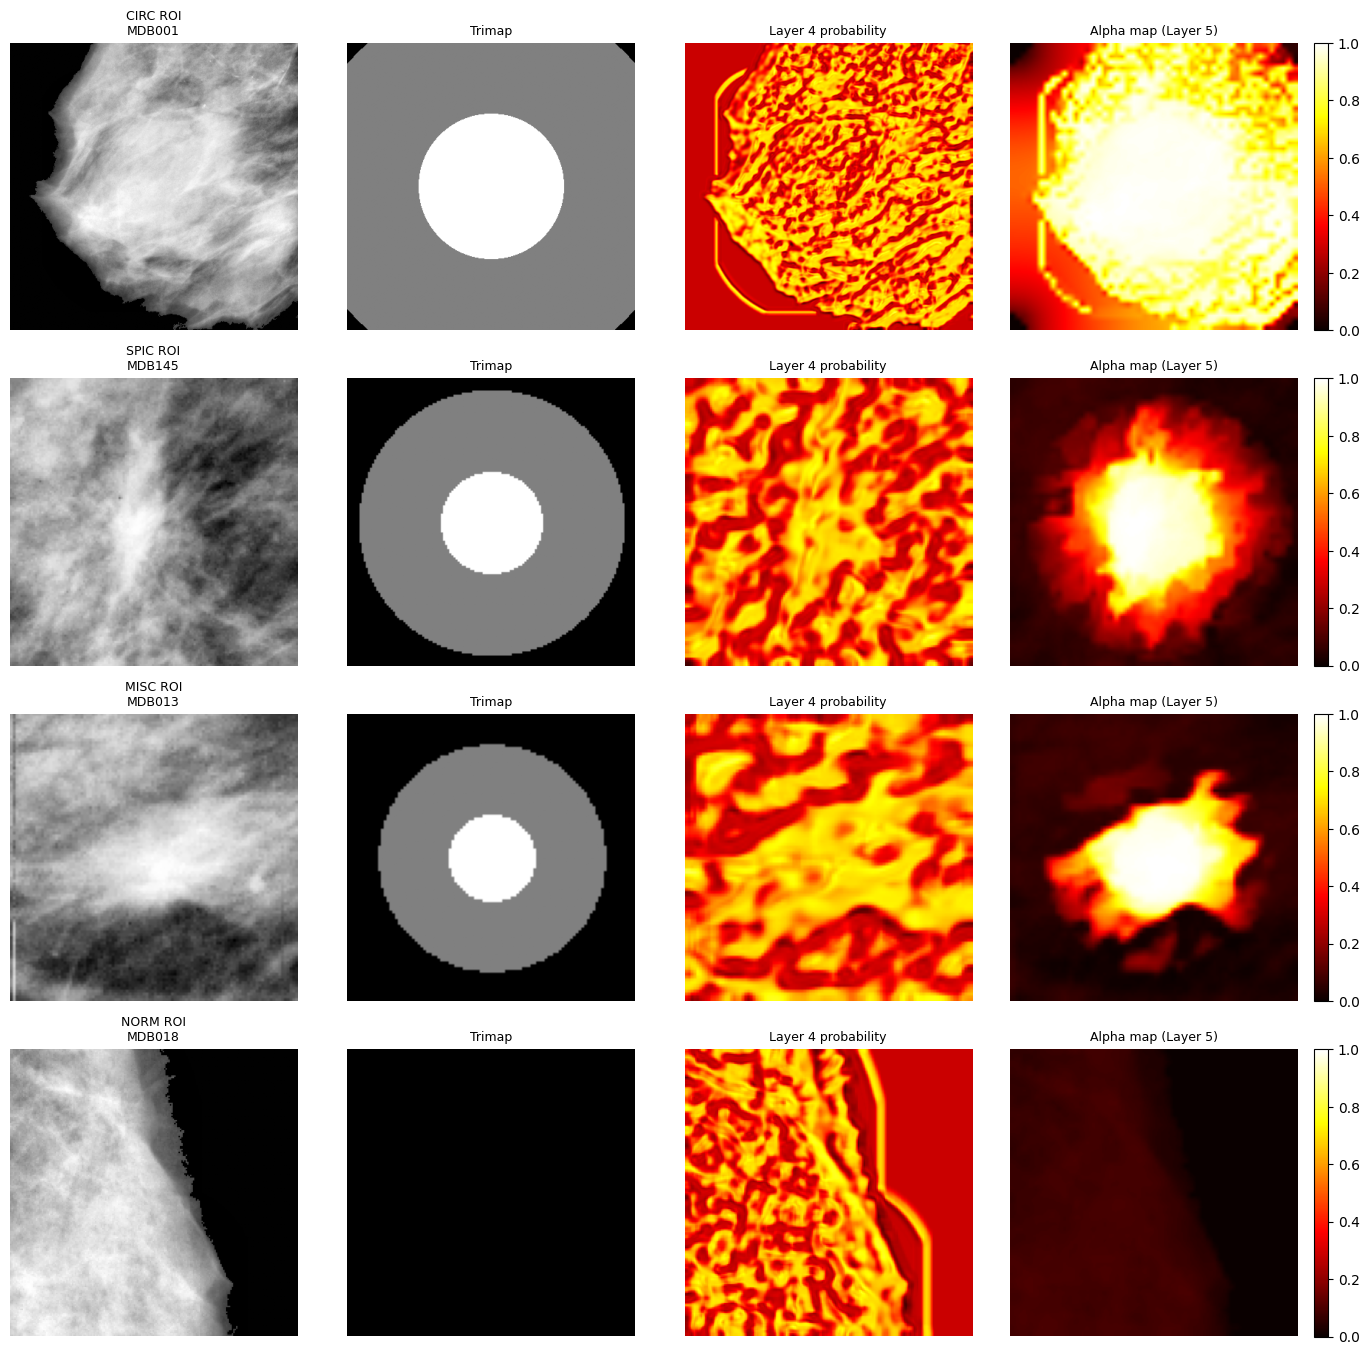

Saved section12_alpha_samples.png


In [ ]:
# Visualise the sample alpha maps
import matplotlib.pyplot as plt

n = len(test_alphas)
if n:
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for r, (cls, d) in enumerate(test_alphas.items()):
        iid = d['image_id']
        roi = preprocessed_results[iid]['roi']
        tm  = preprocessed_results[iid]['trimap']
        pm  = layer4_maps[iid]['prob_map']
        al  = d['alpha']

        axes[r, 0].imshow(roi, cmap='gray')
        axes[r, 0].set_title(f"{cls} ROI\n{iid}", fontsize=9)
        axes[r, 1].imshow(tm if tm is not None else np.zeros_like(roi), cmap='gray')
        axes[r, 1].set_title("Trimap", fontsize=9)
        axes[r, 2].imshow(pm, cmap='hot', vmin=0, vmax=1)
        axes[r, 2].set_title("Layer 4 probability", fontsize=9)
        im = axes[r, 3].imshow(al, cmap='hot', vmin=0, vmax=1)
        axes[r, 3].set_title("Alpha map (Layer 5)", fontsize=9)
        plt.colorbar(im, ax=axes[r, 3], fraction=0.046)
        for c in range(4):
            axes[r, c].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "section12_alpha_samples.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved section12_alpha_samples.png")

In [ ]:
# Batch alpha generation
print("Batch Layer 5 alpha generation...\n")
alpha_maps = {}
t0 = time.time()

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="Layer 5"):
    iid = row['image_id']
    if iid not in layer4_maps:
        continue
    try:
        alpha_maps[iid] = {
            'alpha': solve_alpha(layer4_maps[iid]['prob_map'],
                                 preprocessed_results[iid]['trimap'],
                                 preprocessed_results[iid]['roi']),
            'cls'  : row['class'],
        }
    except Exception as e:
        print(f"  [SKIP] {iid}: {e}")

print(f"\nDone: {len(alpha_maps)} alpha maps in {(time.time()-t0)/60:.1f} min")
np.savez_compressed(
    os.path.join(ALPHAS_DIR, "alpha_maps_full.npz"),
    **{k: v['alpha'] for k, v in alpha_maps.items()}
)
print("Saved alpha_maps_full.npz")

Batch Layer 5 alpha generation...



Layer 5: 100%|██████████| 105/105 [00:46<00:00,  2.24it/s]



Done: 105 alpha maps in 0.8 min
Saved alpha_maps_full.npz


In [ ]:
# Verification
def verify_section12():
    checks = {
        "Alpha maps generated"  : len(alpha_maps) > 0,
        "Alpha in [0,1]"        : all(d['alpha'].min() >= 0 and d['alpha'].max() <= 1
                                      for d in alpha_maps.values()),
        "No NaN"                : all(not np.isnan(d['alpha']).any()
                                      for d in alpha_maps.values()),
        "Alpha is continuous"   : any(len(np.unique(np.round(d['alpha'], 2))) > 5
                                      for d in alpha_maps.values()),
        "Saved to Drive"        : os.path.exists(os.path.join(
                                      ALPHAS_DIR, "alpha_maps_full.npz")),
        "Sample figure saved"   : os.path.exists(os.path.join(
                                      FIGURES_DIR, "section12_alpha_samples.png")),
    }
    print("=" * 52)
    print("SECTION 12 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Ready for Section 13." if ok else "Review failures.")
    return ok

section12_ok = verify_section12()

SECTION 12 VERIFICATION
  OK   Alpha maps generated
  OK   Alpha in [0,1]
  OK   No NaN
  OK   Alpha is continuous
  OK   Saved to Drive
  OK   Sample figure saved
Ready for Section 13.


## Section 13 - Evaluation and the four-arm ablation

Evaluates every alpha map against the circular ground truth, then runs the
ablation.

**On reading the SPIC numbers:** the ground truth is a circle derived from the
MIAS centroid and radius. Spiculations extend beyond any enclosing circle, so SPIC
Dice and HD95 are understated by construction. 

**NORM** has no mass region, so Dice, sensitivity and HD95 are undefined, only specificity and false-positive area apply.

In [ ]:
# Ground truth disc
def make_gt_disc(image_id, df, roi_shape, preprocessed_results):
    row = df[df['image_id'] == image_id]
    if len(row) == 0:
        return None
    row = row.iloc[0]
    if row['class'] == 'NORM':
        return None

    h, w    = roi_shape
    total_r = preprocessed_results[image_id].get('total_r', None)
    radius  = row.get('radius', None)
    if total_r is None or radius is None:
        return None
    if isinstance(radius, float) and np.isnan(radius):
        return None

    scale = (w / 2.0) / float(total_r)
    r_px  = float(radius) * scale

    yy, xx = np.ogrid[:h, :w]
    return ((xx - w / 2.0) ** 2 + (yy - h / 2.0) ** 2) <= r_px ** 2

print("Ground truth disc builder defined.")

Ground truth disc builder defined.


In [ ]:
def dice(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    s = pred.sum() + gt.sum()
    return float(2 * inter / s) if s > 0 else np.nan

def sensitivity(pred, gt):
    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    return float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan

def specificity(pred, gt):
    tn = np.logical_and(~pred, ~gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    return float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan

def hd95(pred, gt):
    """95th-percentile symmetric boundary distance, in pixels."""
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan
    pe = pred ^ ndimage.binary_erosion(pred)
    ge = gt   ^ ndimage.binary_erosion(gt)
    pp, gp = np.argwhere(pe), np.argwhere(ge)
    if len(pp) == 0 or len(gp) == 0:
        return np.nan
    d1 = cdist(pp, gp).min(axis=1)
    d2 = cdist(gp, pp).min(axis=1)
    return float(np.percentile(np.concatenate([d1, d2]), HD95_PERCENTILE))

def alpha_mae(alpha, gt):
    return float(np.abs(alpha - gt.astype(np.float32)).mean())

print("Metrics defined.")

Metrics defined.


In [ ]:
# Per-image evaluation function
def evaluate_alpha(image_id, alpha, df, preprocessed_results, thr=ALPHA_THRESHOLD):
    row = df[df['image_id'] == image_id]
    if len(row) == 0:
        return None
    cls    = row.iloc[0]['class']
    tissue = row.iloc[0].get('tissue', 'NA')
    pred   = alpha >= thr

    if cls == 'NORM':
        # No mass present, so anything predicted as mass is a false positive.
        gt = np.zeros_like(pred, dtype=bool)
        return {
            'image_id': image_id, 'class': cls, 'tissue': tissue,
            'dice': np.nan, 'sensitivity': np.nan,
            'specificity': specificity(pred, gt),
            'hd95': np.nan, 'alpha_mae': alpha_mae(alpha, gt),
            'fp_fraction': float(pred.mean()),
        }

    gt = make_gt_disc(image_id, df, alpha.shape, preprocessed_results)
    if gt is None:
        return None

    return {
        'image_id': image_id, 'class': cls, 'tissue': tissue,
        'dice': dice(pred, gt),
        'sensitivity': sensitivity(pred, gt),
        'specificity': specificity(pred, gt),
        'hd95': hd95(pred, gt),
        'alpha_mae': alpha_mae(alpha, gt),
        'fp_fraction': np.nan,
    }

def summarise(df, group_col='class'):
    out = []
    for g, sub in df.groupby(group_col):
        out.append({
            group_col     : g,
            'n'           : len(sub),
            'dice'        : sub['dice'].mean(),
            'dice_std'    : sub['dice'].std(),
            'sensitivity' : sub['sensitivity'].mean(),
            'specificity' : sub['specificity'].mean(),
            'hd95'        : sub['hd95'].mean(),
            'alpha_mae'   : sub['alpha_mae'].mean(),
        })
    return pd.DataFrame(out)

print("Evaluation and summary functions defined.")

Evaluation and summary functions defined.


In [ ]:
# Evaluate every alpha map
print("Evaluating alpha maps...\n")
rows = []
for iid, d in tqdm(alpha_maps.items(), total=len(alpha_maps), desc="eval"):
    r = evaluate_alpha(iid, d['alpha'], final_df_loaded, preprocessed_results)
    if r:
        rows.append(r)

eval_df = pd.DataFrame(rows)
eval_df.to_csv(os.path.join(RESULTS_DIR, "evaluation_per_image.csv"), index=False)
print(f"\nEvaluated {len(eval_df)} images.")
eval_df.head()

Evaluating alpha maps...



eval: 100%|██████████| 105/105 [00:00<00:00, 321.01it/s]



Evaluated 105 images.


,image_id,class,tissue,dice,sensitivity,specificity,hd95,alpha_mae,fp_fraction
0,MDB001,CIRC,G,0.912095,0.926474,0.580623,45.967380,0.223566,NaN
1,MDB002,CIRC,G,0.869762,0.834504,0.924589,17.088007,0.227265,NaN
2,MDB005,CIRC,F,0.890756,0.807870,0.997632,7.000000,0.136940,NaN
3,MDB010,CIRC,F,0.866273,0.795248,0.982241,9.219544,0.134862,NaN
4,MDB012,CIRC,F,0.766229,0.621294,0.999787,14.317821,0.171920,NaN


In [ ]:
# Per-class and per-tissue summaries
per_class = summarise(eval_df, 'class')
print("Per-class results:")
print(per_class.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
per_class.to_csv(os.path.join(RESULTS_DIR, "evaluation_per_class.csv"), index=False)

print()
print("Reminder: SPIC Dice and HD95 are understated, because the circular ground")
print("truth cannot contain spiculations. Judge SPIC visually as well.")

if 'tissue' in eval_df.columns and eval_df['tissue'].nunique() > 1:
    per_tissue = summarise(eval_df[eval_df['class'] != 'NORM'], 'tissue')
    print("\nPer-tissue results (mass cases only):")
    print(per_tissue.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    per_tissue.to_csv(os.path.join(RESULTS_DIR, "evaluation_per_tissue.csv"), index=False)

Per-class results:
class  n   dice  dice_std  sensitivity  specificity    hd95  alpha_mae
 CIRC 22 0.8416    0.0540       0.7464       0.9704 15.5562     0.1762
 MISC 14 0.8181    0.0539       0.7062       0.9924 14.5282     0.1779
 NORM 50    NaN       NaN          NaN       1.0000     NaN     0.0562
 SPIC 19 0.8099    0.0526       0.7019       0.9749 17.6315     0.1876

Reminder: SPIC Dice and HD95 are understated, because the circular ground
truth cannot contain spiculations. Judge SPIC visually as well.

Per-tissue results (mass cases only):
tissue  n   dice  dice_std  sensitivity  specificity    hd95  alpha_mae
     D 12 0.8408    0.0303       0.7378       0.9896 16.5671     0.1802
     F 23 0.8324    0.0527       0.7340       0.9796 14.3071     0.1657
     G 20 0.8061    0.0638       0.6954       0.9681 17.6380     0.1978


### Ablation arm templates - and the width bug this arm used to hit

The `baseline_3x3_manual` arm swaps the learned K-Means templates for
hand-designed bimodal shape detectors, which is what makes it a baseline.

In [ ]:
# Manual templates for the baseline arm, parametrised to K
def make_manual_templates_k(k, ps=None):
    # Hand-designed bimodal shape detectors, returned as exactly `k` patterns
    ps = PATCH_SINGLE if ps is None else ps
    c  = ps // 2

    def blank():
        return np.full((ps, ps), 0.2, np.float32)

    pool = []
    t = blank(); t[:, c] = 0.9; pool.append(t)                          # vertical
    t = blank(); t[c, :] = 0.9; pool.append(t)                          # horizontal
    t = blank(); np.fill_diagonal(t, 0.9); pool.append(t)               # diagonal
    t = blank(); np.fill_diagonal(np.fliplr(t), 0.9); pool.append(t)    # anti-diagonal
    t = blank(); t[c, :] = 0.9; t[:, c] = 0.9; pool.append(t)           # cross
    t = blank(); t[0, :] = 0.9; t[:, 0] = 0.9; pool.append(t)           # corner
    t = np.full((ps, ps), 0.9, np.float32); t[c, c] = 0.2; pool.append(t)   # blob
    t = blank(); t[c-1:c+2, c-1:c+2] = 0.9; pool.append(t)              # centre block

    t = np.full((ps, ps), 0.9, np.float32)                              # ring + centre
    t[c-1:c+2, c-1:c+2] = 0.2; t[c, c] = 0.9; pool.append(t)
    t = np.full((ps, ps), 0.9, np.float32)                              # ring
    t[c-1:c+2, c-1:c+2] = 0.2; pool.append(t)

    t = blank(); t[:, 0] = 0.9; t[:, -1] = 0.9; pool.append(t)          # double vertical
    t = blank(); t[0, :] = 0.9; t[-1, :] = 0.9; pool.append(t)          # double horizontal

    out, i = list(pool), 0
    while len(out) < k:
        out.append(np.rot90(pool[i % 8], 1 + (i // 8)))
        i += 1
        if i == 1:
            print(f"  note: k={k} exceeds the {len(pool)}-pattern design pool; "
                  "appending rotations, which may duplicate existing patterns.")
    return np.stack(out[:k]).astype(np.float32)

EXPECTED_WIDTH = scaler.mean_.shape[0]

manual_templates = make_manual_templates_k(EXPECTED_WIDTH)
mt = manual_templates
print(f"Manual templates: {manual_templates.shape}  (K_TEMPLATES={K_TEMPLATES}, "
      f"SVM expects {EXPECTED_WIDTH})")
print(f"  high {int((mt>=0.7).sum())}, low {int((mt<=0.3).sum())}, "
      f"medium {int(((mt>0.3)&(mt<0.7)).sum())}")
print("Bimodal by construction, unlike the K-Means centroids.")

assert manual_templates.shape[0] == EXPECTED_WIDTH, (
    f"Manual template count {manual_templates.shape[0]} != SVM input width "
    f"{EXPECTED_WIDTH}. The baseline arm would produce no results.")
print("Width matches the trained SVM, so the baseline arm will produce results.")


Manual templates: (10, 5, 5)  (K_TEMPLATES=10, SVM expects 10)
  high 104, low 146, medium 0
Bimodal by construction, unlike the K-Means centroids.
Width matches the trained SVM, so the baseline arm will produce results.


In [ ]:
# Ablation arm runner
def run_ablation_arm(key, scales, tmpl, use_hybrid, subset_ids=None):
    """Runs Layer 2 -> 3 -> 4 -> 5 -> evaluation for one configuration.
    subset_ids limits the arm to a subset of images to keep runtime sane."""
    print(f"\n{'='*54}")
    print(f"Ablation arm: {key}")
    print(f"{'='*54}")
    print(f"  scales={scales}  templates={tmpl.shape[0]}  hybrid={use_hybrid}")

    ids  = subset_ids if subset_ids is not None else list(alpha_maps.keys())
    rows = []

    for iid in tqdm(ids, desc=key):
        if iid not in layer1_ms_maps:
            continue

        stack = layer1_ms_maps[iid]['lipw_stack']
        sel   = [PATCH_SIZES.index(s) for s in scales]
        lipw  = stack[:, :, sel].mean(axis=2) if len(sel) > 1 else stack[:, :, sel[0]]

        sm = match_templates_signed(lipw, tmpl)
        hm = compute_histogram_map_fast(sm, HISTOGRAM_WINDOW, HISTOGRAM_STRIDE)

        if hm.shape[2] != EXPECTED_WIDTH:
            print(f"  [ABORT] {key}: feature width {hm.shape[2]} != SVM width "
                  f"{EXPECTED_WIDTH}. Template count and K are out of step.")
            return None
        pm = predict_prob_map(hm, svm, scaler)

        # Layer 5
        a = solve_alpha(pm, preprocessed_results[iid]['trimap'],
                        preprocessed_results[iid]['roi'], use_hybrid=use_hybrid)

        r = evaluate_alpha(iid, a, final_df_loaded, preprocessed_results)
        if r:
            rows.append(r)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        print("  no results — every image was skipped; check the width guard above")
        return None

    mass = df[df['class'] != 'NORM']
    summary = {
        'key'         : key,
        'n'           : len(df),
        'dice'        : float(mass['dice'].mean()),
        'sensitivity' : float(mass['sensitivity'].mean()),
        'specificity' : float(df['specificity'].mean()),
        'hd95'        : float(mass['hd95'].mean()),
        'alpha_mae'   : float(df['alpha_mae'].mean()),
    }
    print(f"  Dice={summary['dice']:.4f}  Sens={summary['sensitivity']:.4f}  "
          f"Spec={summary['specificity']:.4f}  MAE={summary['alpha_mae']:.4f}")
    return {'summary': summary, 'per_image': df}

print("Ablation runner defined.")

Ablation runner defined.


In [ ]:
# Run all four arms on a stratified subset
rng_ab = np.random.default_rng(SEED)
subset = []
for cls in TARGET_CLASSES:
    ids = [r['image_id'] for _, r in final_df_loaded.iterrows()
           if r['class'] == cls and r['image_id'] in alpha_maps]
    if ids:
        take = min(ABLATION_N_PER_CLASS, len(ids))
        subset.extend(list(rng_ab.choice(ids, take, replace=False)))

print(f"Ablation subset: {len(subset)} images "
      f"({ABLATION_N_PER_CLASS} per class where available)")
print("The full grid on all 105 images is too slow on Colab CPU. This is a stated")
print("compromise, recorded in the results summary.\n")

arms = [
    ("baseline_3x3_manual",   [3],       manual_templates, False),
    ("mod2_5x5_single_scale", [5],       templates,        False),
    ("mod1234_no_hybrid",     [3, 5, 7], templates,        False),
    ("full_method",           [3, 5, 7], templates,        True),
]

ablation_out = {}
for key, scales, tmpl, hyb in arms:
    res = run_ablation_arm(key, scales, tmpl, hyb, subset_ids=subset)
    if res:
        ablation_out[key] = res

missing = [k for k in ABLATION_KEYS if k not in ablation_out]
assert not missing, (
    f"Ablation arms produced no results: {missing}. Do not proceed to Section 14 "
    "with a partial table — check the feature-width report printed above.")

ablation_table = pd.DataFrame([v['summary'] for v in ablation_out.values()])
ablation_table = ablation_table.set_index('key').loc[ABLATION_KEYS].reset_index()
print("\n" + "=" * 70)
print("ABLATION SUMMARY")
print("=" * 70)
print(ablation_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
ablation_table.to_csv(os.path.join(RESULTS_DIR, "ablation_table.csv"), index=False)

Ablation subset: 32 images (8 per class where available)
The full grid on all 105 images is too slow on Colab CPU. This is a stated
compromise, recorded in the results summary.


Ablation arm: baseline_3x3_manual
  scales=[3]  templates=10  hybrid=False


baseline_3x3_manual: 100%|██████████| 32/32 [17:07<00:00, 32.12s/it]


  Dice=0.8072  Sens=0.6941  Spec=0.9832  MAE=0.1199

Ablation arm: mod2_5x5_single_scale
  scales=[5]  templates=10  hybrid=False


mod2_5x5_single_scale: 100%|██████████| 32/32 [16:59<00:00, 31.87s/it]


  Dice=0.8114  Sens=0.7029  Spec=0.9833  MAE=0.1185

Ablation arm: mod1234_no_hybrid
  scales=[3, 5, 7]  templates=10  hybrid=False


mod1234_no_hybrid: 100%|██████████| 32/32 [17:02<00:00, 31.97s/it]


  Dice=0.8110  Sens=0.7026  Spec=0.9833  MAE=0.1184

Ablation arm: full_method
  scales=[3, 5, 7]  templates=10  hybrid=True


full_method: 100%|██████████| 32/32 [16:58<00:00, 31.81s/it]

  Dice=0.8142  Sens=0.7078  Spec=0.9837  MAE=0.1517

ABLATION SUMMARY
                  key  n   dice  sensitivity  specificity    hd95  alpha_mae
  baseline_3x3_manual 32 0.8072       0.6941       0.9832 15.7766     0.1199
mod2_5x5_single_scale 32 0.8114       0.7029       0.9833 16.5056     0.1185
    mod1234_no_hybrid 32 0.8110       0.7026       0.9833 16.4898     0.1184
          full_method 32 0.8142       0.7078       0.9837 16.3079     0.1517


In [ ]:
# Verification
def verify_section13():
    has_norm = (eval_df['class'] == 'NORM').any()
    checks = {
        "Per-image evaluation"   : len(eval_df) > 0,
        "Per-class table"        : len(per_class) > 0,
        "Dice for mass cases"    : eval_df[eval_df['class'] != 'NORM']['dice'].notna().any(),
        "Specificity for NORM"   : (eval_df[eval_df['class'] == 'NORM']['specificity']
                                    .notna().any()) if has_norm else True,
        "Ablation ran all arms"  : len(ablation_out) == len(ABLATION_KEYS),
        "Results saved"          : os.path.exists(os.path.join(
                                       RESULTS_DIR, "evaluation_per_image.csv")),
    }
    print("=" * 52)
    print("SECTION 13 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Ready for Section 14." if ok else "Review failures.")
    return ok

section13_ok = verify_section13()

SECTION 13 VERIFICATION
  OK   Per-image evaluation
  OK   Per-class table
  OK   Dice for mass cases
  OK   Specificity for NORM
  OK   Ablation ran all arms
  OK   Results saved
Ready for Section 14.


## Section 14 - Consolidation

Writes every result into a single `final_results.json` plus a plain-text
`results_summary.txt` for the report.

In [ ]:
ablation_table = pd.read_csv(os.path.join(RESULTS_DIR, "ablation_table.csv"))
print(f"Ablation table: {len(ablation_table)} arms")
assert len(ablation_table) == len(ABLATION_KEYS), \
    f"Expected {len(ABLATION_KEYS)} ablation arms, found {len(ablation_table)}"

Ablation table: 4 arms


In [ ]:
# Consolidate results
with open(os.path.join(RESULTS_DIR, "template_utilisation.json")) as f:
    _tu = json.load(f)
usage_new = np.array(_tu['after']['usage_pct'])
print(f"usage_new restored: {len(usage_new)} templates, "
      f"{_tu['after']['unused']} unused (<0.1%)")

with open(os.path.join(RESULTS_DIR, "svm_results.json")) as f:
    svm_results = json.load(f)
print(f"svm_results restored: test_acc={svm_results['test_acc']:.4f}")

final_results = {
    'project'    : 'GrC-Based Image Matting on MIAS',
    'base_paper' : 'Hu, Pang, Shi (2016), Knowledge-Based Systems 102, 51-63',
    'dataset'    : {
        'name'   : 'MIAS',
        'cases'  : int(len(final_df_loaded)),
        'classes': {c: int((final_df_loaded['class'] == c).sum()) for c in TARGET_CLASSES},
    },
    'config'     : {
        'seed'            : SEED,
        'patch_sizes'     : PATCH_SIZES,
        'K_templates'     : int(K_TEMPLATES),
        'histogram_window': HISTOGRAM_WINDOW,
        'hybrid_gamma'    : HYBRID_GAMMA,
        'max_nodes'       : MAX_NODES,
        'alpha_threshold' : ALPHA_THRESHOLD,
    },
    'layer2_fix' : {
        'issue'        : 'three-way threshold matcher ignored the template value in '
                         'the medium band, so 6 of 8 templates were unused',
        'fix'          : 'signed-weight matching per paper Section 5.2 and Eq. 37',
        'before_unused': 6,
        'after_unused' : int((usage_new < 0.1).sum()),
    },
    'svm'        : svm_results,
    'per_class'  : per_class.to_dict(orient='records'),
    'ablation'   : ablation_table.to_dict(orient='records'),
    'n_alpha_maps': len(alpha_maps),
}

with open(os.path.join(RESULTS_DIR, "final_results.json"), 'w') as f:
    json.dump(final_results, f, indent=2, default=float)

print("Saved final_results.json")
print(json.dumps({k: v for k, v in final_results.items()
                  if k in ['dataset', 'config', 'layer2_fix']}, indent=2, default=float))

usage_new restored: 10 templates, 0 unused (<0.1%)
svm_results restored: test_acc=0.6279
Saved final_results.json
{
  "dataset": {
    "name": "MIAS",
    "cases": 105,
    "classes": {
      "CIRC": 22,
      "SPIC": 19,
      "MISC": 14,
      "NORM": 50
    }
  },
  "config": {
    "seed": 42,
    "patch_sizes": [
      3,
      5,
      7
    ],
    "K_templates": 10,
    "histogram_window": 7,
    "hybrid_gamma": 0.9,
    "max_nodes": 2500,
    "alpha_threshold": 0.5
  },
  "layer2_fix": {
    "issue": "three-way threshold matcher ignored the template value in the medium band, so 6 of 8 templates were unused",
    "fix": "signed-weight matching per paper Section 5.2 and Eq. 37",
    "before_unused": 6,
    "after_unused": 0
  }
}


In [ ]:
# Plain-text summary for the report
lines = []
lines.append("GrC IMAGE MATTING ON MIAS - RESULTS SUMMARY")
lines.append("=" * 52)
lines.append("")
lines.append(f"Cases evaluated : {len(eval_df)}")
lines.append(f"Templates (K)   : {K_TEMPLATES}")
lines.append(f"SVM test acc    : {svm_results['test_acc']:.4f}")
lines.append(f"SVM params      : {svm_results['best_params']}")
lines.append("")
lines.append("Layer 2 fix")
lines.append("-" * 52)
lines.append("Before: 6 of 8 templates unused, histogram had 2 distinct values.")
lines.append(f"After : {int((usage_new<0.1).sum())} of {K_TEMPLATES} templates unused.")
lines.append("")
lines.append("Per-class results")
lines.append("-" * 52)
lines.append(per_class.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
lines.append("")
lines.append("Ablation")
lines.append("-" * 52)
lines.append(ablation_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
lines.append("")
lines.append("Notes")
lines.append("-" * 52)
lines.append("1. Ground truth is a circle from the MIAS centre and radius annotation.")
lines.append("   SPIC Dice and HD95 are understated, because spiculations extend past")
lines.append("   any enclosing circle. SPIC is judged visually as well.")
lines.append("2. NORM has no mass, so only specificity and false-positive area apply.")
lines.append(f"3. Layer 5 solves on a grid capped at {MAX_NODES} nodes, then resizes.")
lines.append("   This is a compute compromise on Colab CPU.")
lines.append(f"4. The ablation runs on {ABLATION_N_PER_CLASS} images per class, same reason.")
lines.append("5. Layer 4 uses an sklearn RBF-SVM in place of the paper's PSVM.")

summary = "\n".join(lines)
with open(os.path.join(RESULTS_DIR, "results_summary.txt"), 'w') as f:
    f.write(summary)
print(summary)

GrC IMAGE MATTING ON MIAS - RESULTS SUMMARY

Cases evaluated : 105
Templates (K)   : 10
SVM test acc    : 0.6279
SVM params      : {'C': 10, 'gamma': 'auto'}

Layer 2 fix
----------------------------------------------------
Before: 6 of 8 templates unused, histogram had 2 distinct values.
After : 0 of 10 templates unused.

Per-class results
----------------------------------------------------
class  n   dice  dice_std  sensitivity  specificity    hd95  alpha_mae
 CIRC 22 0.8416    0.0540       0.7464       0.9704 15.5562     0.1762
 MISC 14 0.8181    0.0539       0.7062       0.9924 14.5282     0.1779
 NORM 50    NaN       NaN          NaN       1.0000     NaN     0.0562
 SPIC 19 0.8099    0.0526       0.7019       0.9749 17.6315     0.1876

Ablation
----------------------------------------------------
                  key  n   dice  sensitivity  specificity    hd95  alpha_mae
  baseline_3x3_manual 32 0.8072       0.6941       0.9832 15.7766     0.1199
mod2_5x5_single_scale 32 0.8114 

In [ ]:
print("=" * 60)
print("SECTION 14 - OUTPUT INVENTORY")
print("=" * 60)

expected = [
    (OUTPUTS_DIR, "layer2_score_maps_signed.npz"),
    (OUTPUTS_DIR, "layer3_histogram_maps_signed.npz"),
    (OUTPUTS_DIR, "layer4_prob_maps.npz"),
    (ALPHAS_DIR,  "alpha_maps_full.npz"),
    (MODELS_DIR,  "svm_layer4.joblib"),
    (MODELS_DIR,  "svm_scaler.joblib"),
    (RESULTS_DIR, "svm_results.json"),
    (RESULTS_DIR, "template_utilisation.json"),
    (RESULTS_DIR, "evaluation_per_image.csv"),
    (RESULTS_DIR, "evaluation_per_class.csv"),
    (RESULTS_DIR, "ablation_table.csv"),
    (RESULTS_DIR, "final_results.json"),
    (RESULTS_DIR, "results_summary.txt"),
    (FIGURES_DIR, "section12_alpha_samples.png"),
]

all_ok = True
for d, f in expected:
    p = os.path.join(d, f)
    if os.path.exists(p):
        print(f"  OK   {f:<40} {os.path.getsize(p)/1024:8.1f} KB")
    else:
        print(f"  MISS {f}")
        all_ok = False

print("=" * 60)
print("Sections 9 to 14 complete." if all_ok else "Some outputs missing.")
print("Next: run GrC_MIAS_report_diagrams.ipynb to build the report figures.")
print("=" * 60)

SECTION 14 - OUTPUT INVENTORY
  OK   layer2_score_maps_signed.npz             114715.2 KB
  OK   layer3_histogram_maps_signed.npz         116202.5 KB
  OK   layer4_prob_maps.npz                      11649.6 KB
  OK   alpha_maps_full.npz                       11127.9 KB
  OK   svm_layer4.joblib                          1467.0 KB
  OK   svm_scaler.joblib                             0.8 KB
  OK   svm_results.json                              0.2 KB
  OK   template_utilisation.json                     0.4 KB
  OK   evaluation_per_image.csv                      7.9 KB
  OK   evaluation_per_class.csv                      0.5 KB
  OK   ablation_table.csv                            0.5 KB
  OK   final_results.json                            3.1 KB
  OK   results_summary.txt                           1.8 KB
  OK   section12_alpha_samples.png                1050.2 KB
Sections 9 to 14 complete.
Next: run GrC_MIAS_report_diagrams.ipynb to build the report figures.
